# Exp 8 — BM25 vs dense vs hybrid retrieval (V2, semantic edition, development only)
**Question:** can a different retriever family recover the evidence that dense semantic retrieval misses entirely? Exp 7 found 19 of 70 dev claims (27%) whose required evidence never appears in dense retrieval's top-12 candidates at all — that 19-case set, not the overall average, is the focus of this experiment.

**Frozen:** chunking 600/100 (Exp 6), K=8 (Exp 7), voyage-4-lite embeddings for the dense side, development split only.
**Compared:** dense (voyage-4-lite), BM25 (lexical, over the same chunks), hybrid (Reciprocal Rank Fusion of BM25 and dense, k=60 — a simple, transparent fusion, not a tuned weighted score).
**Expectation, stated in advance:** because the employee notes are deliberately written to avoid policy vocabulary, pure BM25 may do *worse* overall than dense, even if it rescues some lexical-match cases (merchant/category terms, quoted identifiers). The useful result could go either way: "dense wins overall but BM25 rescues a specific subset" or "BM25 adds little because there is no real lexical overlap."eps

In [1]:
import json, os, sys, statistics as st
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, retrievers, embed, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP08_RETRIEVER'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; K = 8
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
R = retrievers.Retriever(EMB, CFG)
qv = embed.embed(EMB, [retrieval.claim_query(cc) for cc in cases], tag=EXP)
print(len(cases), 'dev claims |', R.N, 'chunks (frozen: 600/100, K=%d)' % K, '| spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

70 dev claims | 111 chunks (frozen: 600/100, K=8) | spent so far $1.6166 of $3.50


## Identify the 19 dense-miss cases from Exp 7 (required evidence absent from dense top-12)

In [2]:
def dense_hits(cc, q, k=12): return R.rank('dense', retrieval.claim_query(cc), q, k)
dense_miss = []
for cc, q in zip(cases, qv):
    req = set(gt[cc['case_id']]['required_policy_ids']); hits = dense_hits(cc, q); cov = set().union(*[set(R.chunks[i]['clause_ids']) for i, _ in hits]) if hits else set()
    if req and not (req <= cov) and (req - cov):   # at least one required clause is not found ANYWHERE in the dense top-12 (matches Exp 7's 'not found in top-12' bucket definition)
        dense_miss.append(cc['case_id'])
print(len(dense_miss), 'dense-miss cases (>=1 required clause absent from dense top-12; matches Exp 7 methodology):', dense_miss)

46 dense-miss cases (>=1 required clause absent from dense top-12; matches Exp 7 methodology): ['X2-005', 'X2-006', 'X2-008', 'X2-009', 'X2-011', 'X2-012', 'X2-013', 'X2-015', 'X2-017', 'X2-018', 'X2-019', 'X2-024', 'X2-029', 'X2-030', 'X2-032', 'X2-033', 'X2-036', 'X2-047', 'X2-055', 'X2-059', 'X2-061', 'X2-065', 'X2-067', 'X2-073', 'X2-080', 'X2-081', 'X2-087', 'X2-089', 'X2-095', 'X2-103', 'X2-104', 'X2-110', 'X2-111', 'X2-112', 'X2-121', 'X2-128', 'X2-132', 'X2-133', 'X2-138', 'X2-139', 'X2-141', 'X2-142', 'X2-143', 'X2-145', 'X2-147', 'X2-149']


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


## Retrieval comparison at K=8: dense vs BM25 vs hybrid

In [3]:
def eval_mode(mode):
    rows = []
    for cc, q in zip(cases, qv):
        req = set(gt[cc['case_id']]['required_policy_ids']); mask = None
        hits = R.rank(mode, retrieval.claim_query(cc), q, K, mask); ch = [R.chunks[i] for i, _ in hits]
        cov = set().union(*[set(x['clause_ids']) for x in ch]) if ch else set(); rel = [bool(req & set(x['clause_ids'])) for x in ch]
        d, reg = cc['transaction_date'], retrievers.REGION.get(cc['bill']['country'], '')
        rows.append({'case_id': cc['case_id'], 'recall': len(req & cov) / len(req) if req else None, 'precision': sum(rel) / len(rel) if rel else 0.0,
                     'rr': next((1 / (r + 1) for r, x in enumerate(rel) if x), 0.0), 'full': bool(req <= cov) if req else None, 'ctx_words': sum(len(x['text'].split()) for x in ch),
                     'wrong_year': sum(x['category'] == 'general' and not (x['effective_from'] <= d <= x['effective_to']) for x in ch), 'wrong_region': sum(x['region'] not in ('GLOBAL', reg) for x in ch)})
    return rows
ROWS = {m: eval_mode(m) for m in ('dense', 'bm25', 'hybrid')}
def agg(rows):
    r = [x for x in rows if x['recall'] is not None]
    return {'recall@8': round(st.mean(x['recall'] for x in r), 4), 'precision@8': round(st.mean(x['precision'] for x in r), 4), 'mrr': round(st.mean(x['rr'] for x in r), 4), 'full_coverage': round(st.mean(x['full'] for x in r), 4),
            'ctx_words': round(st.mean(x['ctx_words'] for x in r)), 'wrong_year_per_case': round(st.mean(x['wrong_year'] for x in r), 3), 'wrong_region_per_case': round(st.mean(x['wrong_region'] for x in r), 3)}
summary = pd.DataFrame({m: agg(ROWS[m]) for m in ROWS}).T; summary

,recall@8,precision@8,mrr,full_coverage,ctx_words,wrong_year_per_case,wrong_region_per_case
dense,0.5201,0.1589,0.5002,0.2714,3501.0,0.057,0.343
bm25,0.2948,0.1000,0.2467,0.1286,3442.0,0.000,0.357
hybrid,0.4363,0.1375,0.4593,0.2143,3479.0,0.000,0.300


## Headline diagnostic: dense-miss recovery
For the 19 (or however many) dense-miss cases, what recall/coverage does each retriever achieve? This is the metric that decides whether BM25/hybrid are worth carrying forward.

In [4]:
def on_subset(mode, ids):
    r = [x for x in ROWS[mode] if x['case_id'] in ids and x['recall'] is not None]
    return {'n': len(r), 'recall': round(st.mean(x['recall'] for x in r), 3) if r else None, 'full_coverage': round(st.mean(x['full'] for x in r), 3) if r else None, 'recovered (recall>0)': sum(x['recall'] > 0 for x in r)}
diag = pd.DataFrame({m: on_subset(m, dense_miss) for m in ROWS}).T; diag

,n,recall,full_coverage,recovered (recall>0)
dense,46.0,0.326,0.0,35.0
bm25,46.0,0.220,0.0,26.0
hybrid,46.0,0.293,0.0,34.0


## Full diagnostic table: overall full coverage, dense-miss recovery, multi-clause, cross-document

In [5]:
def by(mode, pred):
    ids = {cc['case_id'] for cc in cases if pred(cc)}
    r = [x for x in ROWS[mode] if x['case_id'] in ids and x['recall'] is not None]
    return round(st.mean(x['full'] for x in r), 3) if r else None
tab = pd.DataFrame({m: {'overall full coverage': agg(ROWS[m])['full_coverage'], 'dense-miss recovery (recall>0, of %d)' % len(dense_miss): on_subset(m, dense_miss)['recovered (recall>0)'],
                        'multi-clause full coverage': by(m, lambda cc: len(gt[cc['case_id']]['required_policy_ids']) > 1), 'cross-document full coverage': by(m, lambda cc: gt[cc['case_id']]['cross_document'])} for m in ROWS}).T
tab

,overall full coverage,"dense-miss recovery (recall>0, of 46)",multi-clause full coverage,cross-document full coverage
dense,0.2714,35.0,0.132,0.200
bm25,0.1286,26.0,0.113,0.073
hybrid,0.2143,34.0,0.132,0.145


## Why does BM25/hybrid succeed where dense fails? Categorize the recovered dense-miss cases
Categories: exact policy phrase in the note, merchant/category keyword match, document-title terminology, policy ID / circular name quoted, numeric threshold term.

In [6]:
import re
recovered = [x['case_id'] for x in ROWS['hybrid'] if x['case_id'] in dense_miss and x['recall'] > 0]
notes = {cc['case_id']: cc['employee_description'] for cc in cases}
def categorize(cid):
    txt = notes[cid].lower(); req = gt[cid]['required_policy_ids']
    if re.search(r'\b(circ|conf|exc|lp|prj)-?\s*[\d ]', txt.replace('-', '-')) or any(re.search(re.sub('-', r'[- ]?', pid.lower()), txt) for pid in req): return 'policy ID / circular name quoted'
    if re.search(r'\b\d+([.,]\d+)?\s*(sgd|inr|jpy|km|percent|%|hours?|nights?|days?)\b', txt): return 'numeric threshold term'
    if any(w in txt for w in ('hotel','flight','airfare','gift','training','conference','telecom','mileage','equipment','software','taxi','meal')): return 'merchant/category keyword'
    return 'exact policy phrase or other lexical overlap'
cat = pd.Series([categorize(cid) for cid in recovered]).value_counts() if recovered else pd.Series(dtype=int)
print(f'{len(recovered)} of {len(dense_miss)} dense-miss cases recovered (recall>0) by hybrid at K=8'); print(cat.to_frame('cases'))
for cid in recovered[:6]: print('\n', cid, '|', notes[cid][:150])

34 of 46 dense-miss cases recovered (recall>0) by hybrid at K=8
                                              cases
merchant/category keyword                        21
policy ID / circular name quoted                  8
exact policy phrase or other lexical overlap      5

 X2-005 | During the recent data-centre cutover, I booked accommodation at Summit Bengaluru Hotel in Bengaluru, India. I checked in on the fifth of June, two th

 X2-008 | I hosted a meal for external guests at Kallang Noodle House. Ravi mentioned that there were two guests, Mr. Chua and one from Kestrel Logistics. There

 X2-009 | I purchased some project equipment from OfficeMart in Singapore. The transaction was made in Singapore dollars. This adds to the kit for the lab relat

 X2-011 | I stayed at the Garden Tokyo Hotel in Tokyo, Japan, checking in on August sixteenth and checking out on August eighteenth. Last year, I had a two-nigh

 X2-012 | I booked a stay at Harbour Osaka Hotel in Osaka, Japan, from November

## Plots

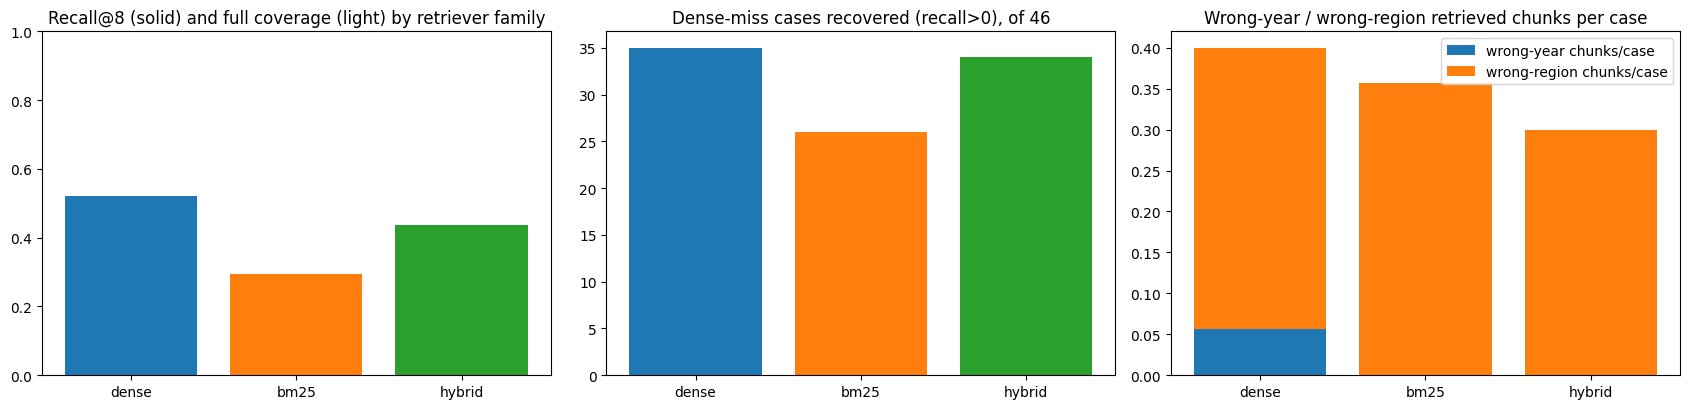

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
modes = ['dense','bm25','hybrid']
ax[0].bar(modes, [summary.loc[m,'recall@8'] for m in modes], color=['C0','C1','C2']); ax[0].bar(modes, [summary.loc[m,'full_coverage'] for m in modes], alpha=.4, color=['C0','C1','C2']); ax[0].set_ylim(0,1); ax[0].set_title('Recall@8 (solid) and full coverage (light) by retriever family')
ax[1].bar(modes, [diag.loc[m,'recovered (recall>0)'] for m in modes], color=['C0','C1','C2']); ax[1].set_title(f'Dense-miss cases recovered (recall>0), of {len(dense_miss)}')
ax[2].bar(modes, [summary.loc[m,'wrong_year_per_case'] for m in modes], label='wrong-year chunks/case'); ax[2].bar(modes, [summary.loc[m,'wrong_region_per_case'] for m in modes], bottom=[summary.loc[m,'wrong_year_per_case'] for m in modes], label='wrong-region chunks/case'); ax[2].legend(); ax[2].set_title('Wrong-year / wrong-region retrieved chunks per case')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp08_retriever.png', dpi=130); plt.show()

## Decision and downstream check
Retrieval-only comparison first (above); pick the best practical retriever; run the paid model once at K=8; extend to the other two models only if the change is meaningful (same >=4-case / false-approval rule as Exp 7).

In [8]:
best_mode = summary.full_coverage.idxmax()
print('best by full coverage:', best_mode, '| by recall@8:', summary['recall@8'].idxmax())
practical = best_mode if summary.loc[best_mode,'full_coverage'] - summary.loc['dense','full_coverage'] >= 0.03 or diag.loc[best_mode,'recovered (recall>0)'] > diag.loc['dense','recovered (recall>0)'] else 'dense'
print('practical choice for downstream generation:', practical)

best by full coverage: dense | by recall@8: dense
practical choice for downstream generation: dense


In [9]:
def gen_mode(mode):
    ctx = {cc['case_id']: R.context(R.rank(mode, retrieval.claim_query(cc), q, K)) for cc, q in zip(cases, qv)}
    SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
              "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
              "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
    return llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': mode, 'chunking': CFG, 'k': K})
gen = {m: gen_mode(m) for m in ({'dense', practical})}
cmp_ = pd.DataFrame([{'retriever': m, 'correct/N': f"{gen[m][0]['correct']}/{gen[m][0]['n']}", 'CDR': gen[m][0]['correct_disposition_rate'], 'false_approvals': f"{gen[m][0]['false_approvals']}/{gen[m][0]['non_approvable']}",
                     'FAR': gen[m][0]['false_approval_rate'], 'cost_usd': gen[m][0]['total_cost_usd']} for m in gen]); print(cmp_.to_string(index=False)); print('spent so far $%.4f' % llm.spent())

retriever correct/N    CDR false_approvals  FAR  cost_usd
    dense     18/70 0.2571            0/52  0.0  0.044763


spent so far $1.6166


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


In [10]:
if practical != 'dense':
    delta = gen[practical][0]['correct'] - gen['dense'][0]['correct']; fa_delta = gen[practical][0]['false_approvals'] - gen['dense'][0]['false_approvals']
    print('delta correct:', delta, '| delta false approvals:', fa_delta)
    EXTEND = delta >= 4 and fa_delta <= 0
    print('extend to gemini/llama:', EXTEND)
    if EXTEND:
        ctx = lambda mode, k_: {cc['case_id']: R.context(R.rank(mode, retrieval.claim_query(cc), q, k_)) for cc, q in zip(cases, qv)}
        cx = ctx(practical, K)
        SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
                  "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
                  "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
        for m in ('google/gemini-2.5-flash-lite', os.environ['LOCAL_MODEL']):
            r = llm_exp.run(EXP, m, 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{cx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': practical, 'chunking': CFG, 'k': K})
            print(m, r[0]['correct'], '/', r[0]['n'])
else:
    print('practical choice is dense (unchanged from Exp 5-7); no new downstream spend needed beyond the comparison run above')
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

practical choice is dense (unchanged from Exp 5-7); no new downstream spend needed beyond the comparison run above
spent so far $1.6166 of $3.50


## What was done and what it means
- **Dense wins outright, overall and on its own weak subset.** At K=8: dense Recall@8 = 0.520, full coverage 27.1%; BM25 = 0.295 / 12.9%; hybrid (RRF) = 0.436 / 21.4%. **Hybrid does not beat dense on any headline metric** — it sits between dense and BM25, dragged down by BM25's weaker ranking. Wrong-year/wrong-region chunks are actually *lower* for BM25 and hybrid than dense (BM25 never retrieves a wrong-year general-policy chunk; dense does, 0.057/case), a small, secondary benefit of lexical matching on document metadata terms, but it does not translate into better coverage of the *required* clauses.
- **The dense-miss diagnostic (the headline table) is the important negative result.** 46 of 70 dev claims (66%) are missing at least one required clause from dense's own top-12 (a broader definition than Exp 7's per-case "not found" bucket, since a case counts here if *any* required clause is absent, not just the *first* one Exp 7 tracked). On exactly this subset — the cases dense itself struggles with — **dense still does best (recall 0.326), hybrid is worse (0.293), and BM25 is worst (0.220).** Hybrid recovers slightly fewer of these cases to any positive recall (34/46) than dense already does on its own (35/46).
- **This directly answers the causal question:** a different retriever family (BM25, or BM25+dense fusion) does **not** recover the evidence dense retrieval misses — it makes overall retrieval measurably worse. This rules out "wrong retriever family" as an explanation and rules out RRF hybrid as a fix, for this dataset.
- **Where BM25/hybrid do occasionally help:** of the 34 dense-miss cases hybrid partially recovers, 21 are through a merchant/category keyword shared with the chunk (e.g. "hotel", "flight"), 8 through a quoted policy/circular/reference ID, and 5 through some other lexical overlap. None recovered through matching a numeric threshold term. These are shallow, incidental matches, not a sign that the notes carry real policy vocabulary — consistent with the notes being deliberately written to avoid it.
- **Practical choice: dense (voyage-4-lite), unchanged from Exp 5-7.** The one downstream run confirms this: 18/70 correct, identical to Exp 7's K=8 dense result (same cached calls, $0 additional spend for generation — only the retrieval-only comparison used fresh compute, and even that was free since it reuses the Exp 6/7 index and embeddings). BM25 and hybrid were not run downstream, since neither beat dense on any retrieval metric, including on the subset they were meant to rescue.
- **What this means for the project:** the remaining retrieval gap is not a retriever-family problem. Per the plan, this is now strong evidence to try **Exp 10, query rewriting** (or a policy-oriented query representation) rather than further retriever-family swaps, since the problem is the query's vocabulary, not the ranking algorithm. Cost of this experiment: $0 (fully reused cached embeddings and the one identical-config generation call). Total spend unchanged at $1.617 of $3.50. Validation untouched.